**A. Membangun Struktur Direktori HDFS** *(bobot 15%)*

In [28]:
df_magelang

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang
...,...,...,...,...,...,...,...
195,MAG-2195,2026-08-09,Makanan & Minuman,1,250000,COD,Magelang
196,MAG-2196,2026-08-28,Fashion,6,250000,COD,Magelang
197,MAG-2197,2026-08-14,Elektronik,1,250000,COD,Magelang
198,MAG-2198,2026-08-02,Makanan & Minuman,6,100000,Transfer Bank,Magelang


In [29]:
df_yogyakarta

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,YOG-2000,2026-08-20,Fashion,5,250000,E-Wallet,Yogyakarta
1,YOG-2001,2026-08-24,Fashion,4,150000,Kartu Kredit,Yogyakarta
2,YOG-2002,2026-08-29,Rumah Tangga,4,100000,E-Wallet,Yogyakarta
3,YOG-2003,2026-08-13,Fashion,7,250000,E-Wallet,Yogyakarta
4,YOG-2004,2026-08-09,Elektronik,7,75000,COD,Yogyakarta
...,...,...,...,...,...,...,...
195,YOG-2195,2026-08-25,Rumah Tangga,4,250000,Kartu Kredit,Yogyakarta
196,YOG-2196,2026-08-18,Fashion,1,150000,COD,Yogyakarta
197,YOG-2197,2026-08-27,Makanan & Minuman,4,25000,Kartu Kredit,Yogyakarta
198,YOG-2198,2026-08-07,Rumah Tangga,1,25000,COD,Yogyakarta


In [30]:
df_semarang

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,SEM-2000,2026-08-28,Elektronik,3,100000,E-Wallet,Semarang
1,SEM-2001,2026-08-29,Kesehatan & Kecantikan,4,25000,Transfer Bank,Semarang
2,SEM-2002,2026-08-19,Rumah Tangga,1,25000,COD,Semarang
3,SEM-2003,2026-08-02,Makanan & Minuman,2,75000,E-Wallet,Semarang
4,SEM-2004,2026-08-05,Elektronik,6,25000,Transfer Bank,Semarang
...,...,...,...,...,...,...,...
195,SEM-2195,2026-08-31,Rumah Tangga,6,75000,Transfer Bank,Semarang
196,SEM-2196,2026-08-15,Kesehatan & Kecantikan,5,75000,Transfer Bank,Semarang
197,SEM-2197,2026-08-01,Makanan & Minuman,4,75000,E-Wallet,Semarang
198,SEM-2198,2026-08-05,Fashion,7,25000,Transfer Bank,Semarang


In [26]:
#A. Membangun Struktur Direktori HDFS

!hdfs dfs -mkdir -p /user/cahyoalim/ecommerce/raw
!hdfs dfs -mkdir -p /user/cahyoalim/ecommerce/processed

!hdfs dfs -ls /user/cahyoalim/ecommerce


Found 2 items
drwxr-xr-x   - cahyoalim supergroup          0 2026-09-08 19:58 /user/cahyoalim/ecommerce/processed
drwxr-xr-x   - cahyoalim supergroup          0 2026-09-08 19:47 /user/cahyoalim/ecommerce/raw


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang


**B. Mengunggah Data Mentah ke HDFS** *(bobot 15%)*

In [9]:
#B. Mengunggah Data Mentah ke HDFS

# Mengunggah 3 file CSV ke HDFS
!hdfs dfs -put transaksi_magelang.csv /user/cahyoalim/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/cahyoalim/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/cahyoalim/ecommerce/raw/

# Verifikasi isi direktori beserta ukurannya
!hdfs dfs -ls /user/cahyoalim/ecommerce/raw

put: `/user/cahyoalim/ecommerce/raw/transaksi_magelang.csv': File exists
put: `/user/cahyoalim/ecommerce/raw/transaksi_yogyakarta.csv': File exists
put: `/user/cahyoalim/ecommerce/raw/transaksi_semarang.csv': File exists
Found 3 items
-rw-r--r--   1 cahyoalim supergroup      12329 2026-09-08 19:47 /user/cahyoalim/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 cahyoalim supergroup      12154 2026-09-08 19:47 /user/cahyoalim/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 cahyoalim supergroup      12684 2026-09-08 19:47 /user/cahyoalim/ecommerce/raw/transaksi_yogyakarta.csv


**C. Membaca Kembali dan Menggabungkan Data dari HDFS** *(bobot 25%)*

In [31]:
#C. Membaca Kembali dan Menggabungkan Data dari HDFS

import pandas as pd

# Membaca data HDFS menggunakan WebHDFS (Port 9870)
host_webhdfs = "http://localhost:9870/webhdfs/v1"
path_raw = "/user/cahyoalim/ecommerce/raw"

df_magelang = pd.read_csv(f"{host_webhdfs}{path_raw}/transaksi_magelang.csv?op=OPEN")
df_yogyakarta = pd.read_csv(f"{host_webhdfs}{path_raw}/transaksi_yogyakarta.csv?op=OPEN")
df_semarang = pd.read_csv(f"{host_webhdfs}{path_raw}/transaksi_semarang.csv?op=OPEN")

# Menggabungkan ketiga DataFrame menjadi satu
df_gabungan = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index=True)

# Membuktikan sukses tergabung dari ketiga kota
print(df_gabungan['kota'].value_counts())

df_gabungan

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang
...,...,...,...,...,...,...,...
595,SEM-2195,2026-08-31,Rumah Tangga,6,75000,Transfer Bank,Semarang
596,SEM-2196,2026-08-15,Kesehatan & Kecantikan,5,75000,Transfer Bank,Semarang
597,SEM-2197,2026-08-01,Makanan & Minuman,4,75000,E-Wallet,Semarang
598,SEM-2198,2026-08-05,Fashion,7,25000,Transfer Bank,Semarang


**D. Mengolah dan Download Hasil ke Direktori `processed`** *(bobot 25%)*

In [32]:
#D. Mengolah dan Download Hasil ke Direktori processed

#Menambahkan kolom total_pendapatan 
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']

#Membuat tabel ringkasan 
df_ringkasan = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

#Menyimpan kedua hasil ke disk lokal lalu diunggah kembali ke HDFS
df_gabungan.to_csv('data_gabungan_bersih.csv', index=False)
df_ringkasan.to_csv('ringkasan_kota_kategori.csv', index=False)

#Mengunggah hasil CSV processed
!hdfs dfs -put data_gabungan_bersih.csv /user/cahyoalim/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/cahyoalim/ecommerce/processed/

# Verifikasi hasil 
!hdfs dfs -ls /user/cahyoalim/ecommerce/processed/





put: `/user/cahyoalim/ecommerce/processed/data_gabungan_bersih.csv': File exists
put: `/user/cahyoalim/ecommerce/processed/ringkasan_kota_kategori.csv': File exists
Found 2 items
-rw-r--r--   1 cahyoalim supergroup      41257 2026-09-08 19:58 /user/cahyoalim/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 cahyoalim supergroup        530 2026-09-08 19:58 /user/cahyoalim/ecommerce/processed/ringkasan_kota_kategori.csv


In [33]:

df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']


df_gabungan

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000
...,...,...,...,...,...,...,...,...
595,SEM-2195,2026-08-31,Rumah Tangga,6,75000,Transfer Bank,Semarang,450000
596,SEM-2196,2026-08-15,Kesehatan & Kecantikan,5,75000,Transfer Bank,Semarang,375000
597,SEM-2197,2026-08-01,Makanan & Minuman,4,75000,E-Wallet,Semarang,300000
598,SEM-2198,2026-08-05,Fashion,7,25000,Transfer Bank,Semarang,175000


In [25]:

df_ringkasan = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

df_ringkasan

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000


**E. Dokumentasi dan Refleksi** *(bobot 20%)*

Sertakan pada notebook anda:
1. **Screenshot** halaman NameNode Web UI (http://localhost:9870, menu *Utilities → Browse the file system*) yang menunjukkan struktur folder `/user/[username]/ecommerce/` beserta isinya (paste gambar ke dalam markdown cell, atau lampirkan terpisah jika format pengumpulan berupa arsip/zip.
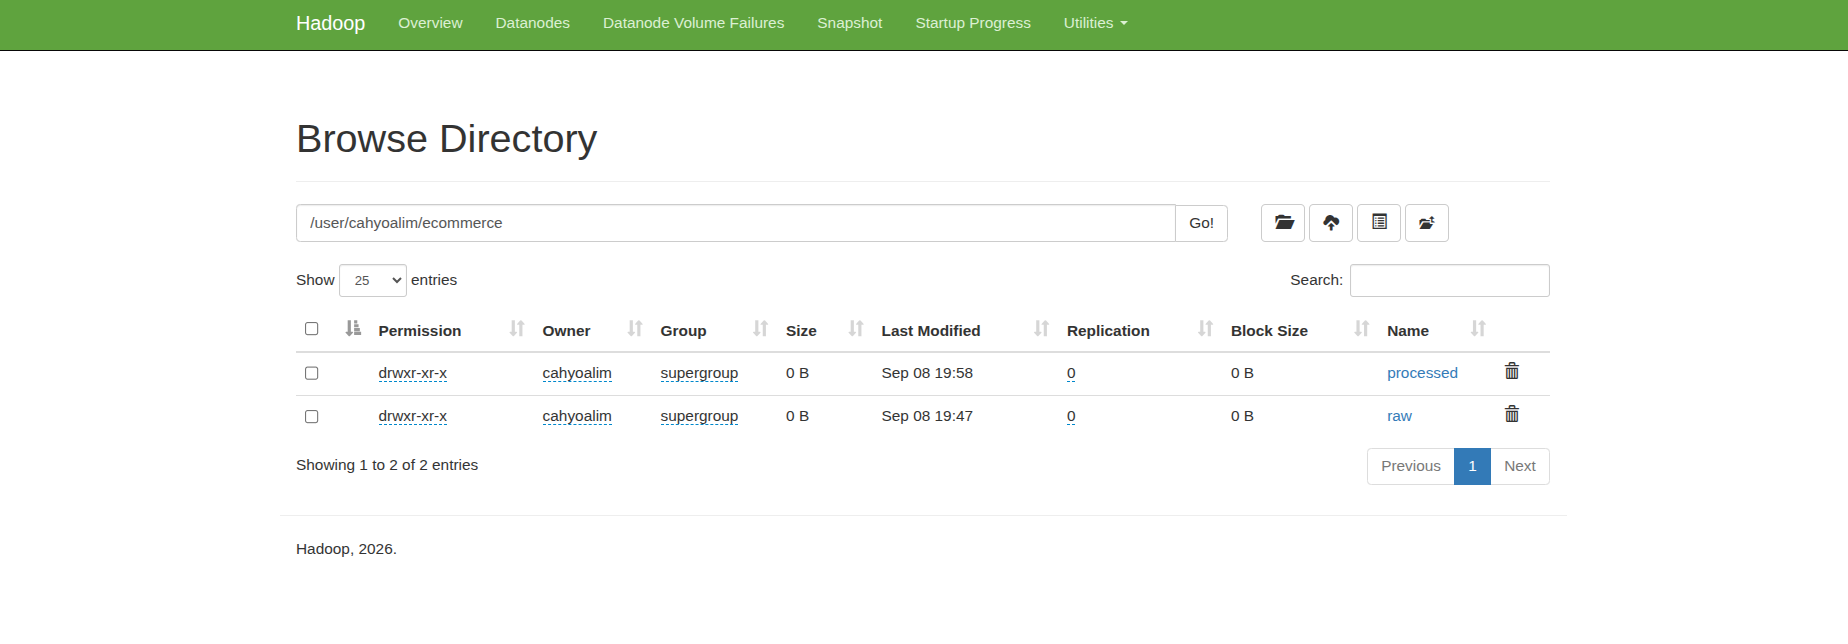

   
3. Tulisan reflektif (**minimal 100 kata**) pada markdown cell yang menjawab: *Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?*

jawaban =
Pemisahan antara direktori mentah dan olaahan di dalam arsitektur penyimpanan HDFS mengadopsi prinsip dasar Data Lakehouse modern yang sangat krusial
. Keuntungan utamanya adalah menjaga integritas data asli. Dengan menyimpan data mentah di folder raw, kita selalu memiliki cadangan data sejarah asli yang tidak akan rusak atau berubah akibat kesalahan logika selama proses pengolahan data
. Selain itu, pemisahan ini mempermudah manajemen hak akses keamanan, di mana tim engineering dapat mengunci folder raw agar bersifat read-only, sementara analis data hanya bekerja dan menulis hasil di folder processed
. Hal ini juga meningkatkan efisiensi pemrosesan karena sistem atau tools Big Data lainnya di masa mendatang tidak perlu membuang waktu memfilter ulang data mentah yang kotor di tengah tumpukan data yang sudah bersih
.
